In [1]:
import pandas as pd
import numpy as np
import os
import joblib

from scipy.sparse import load_npz

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
# load test data
X_test_tfidf = load_npz(
    "../data/processed/X_test_tfidf.npz"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).values.ravel()

print("Test features:", X_test_tfidf.shape)
print("Test labels:", y_test.shape)

Test features: (7831, 10000)
Test labels: (7831,)


In [3]:
# load trained models
lr_model = joblib.load(
    "../models/logistic_regression.pkl"
)

nb_model = joblib.load(
    "../models/naive_bayes.pkl"
)

rf_model = joblib.load(
    "../models/random_forest.pkl"
)

nn_model = joblib.load(
    "../models/neural_network.pkl"
)

print("All models loaded successfully!")

All models loaded successfully!


In [ ]:
# generate predictions for each model - logistic, naive bayes, random forest, and neural network
lr_pred = lr_model.predict(X_test_tfidf)

In [5]:
nb_pred = nb_model.predict(X_test_tfidf)

In [6]:
X_test_rf = X_test_tfidf[:, :5000]

rf_pred = rf_model.predict(X_test_rf)

In [7]:
X_test_nn = X_test_tfidf[:, :3000].toarray()

nn_pred = nn_model.predict(X_test_nn)

In [8]:
# calculate evaluation metrics for each model
models = {
    "Logistic Regression": lr_pred,
    "Naive Bayes": nb_pred,
    "Random Forest": rf_pred,
    "Neural Network": nn_pred
}

evaluation_results = []

for model_name, predictions in models.items():
    
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    
    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.994637,0.994288,0.996109,0.995198
1,Naive Bayes,0.963606,0.998292,0.936370,0.966340
2,Random Forest,0.989401,0.992191,0.988785,0.990485
3,Neural Network,0.978547,0.980114,0.981460,0.980787


In [9]:
# classification report 
for model_name, predictions in models.items():
    
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    
    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "Legitimate",
                "Phishing"
            ]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99      3462
    Phishing       0.99      1.00      1.00      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831

Naive Bayes
              precision    recall  f1-score   support

  Legitimate       0.93      1.00      0.96      3462
    Phishing       1.00      0.94      0.97      4369

    accuracy                           0.96      7831
   macro avg       0.96      0.97      0.96      7831
weighted avg       0.97      0.96      0.96      7831

Random Forest
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3462
    Phishing       0.99      0.99      0.99      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99     

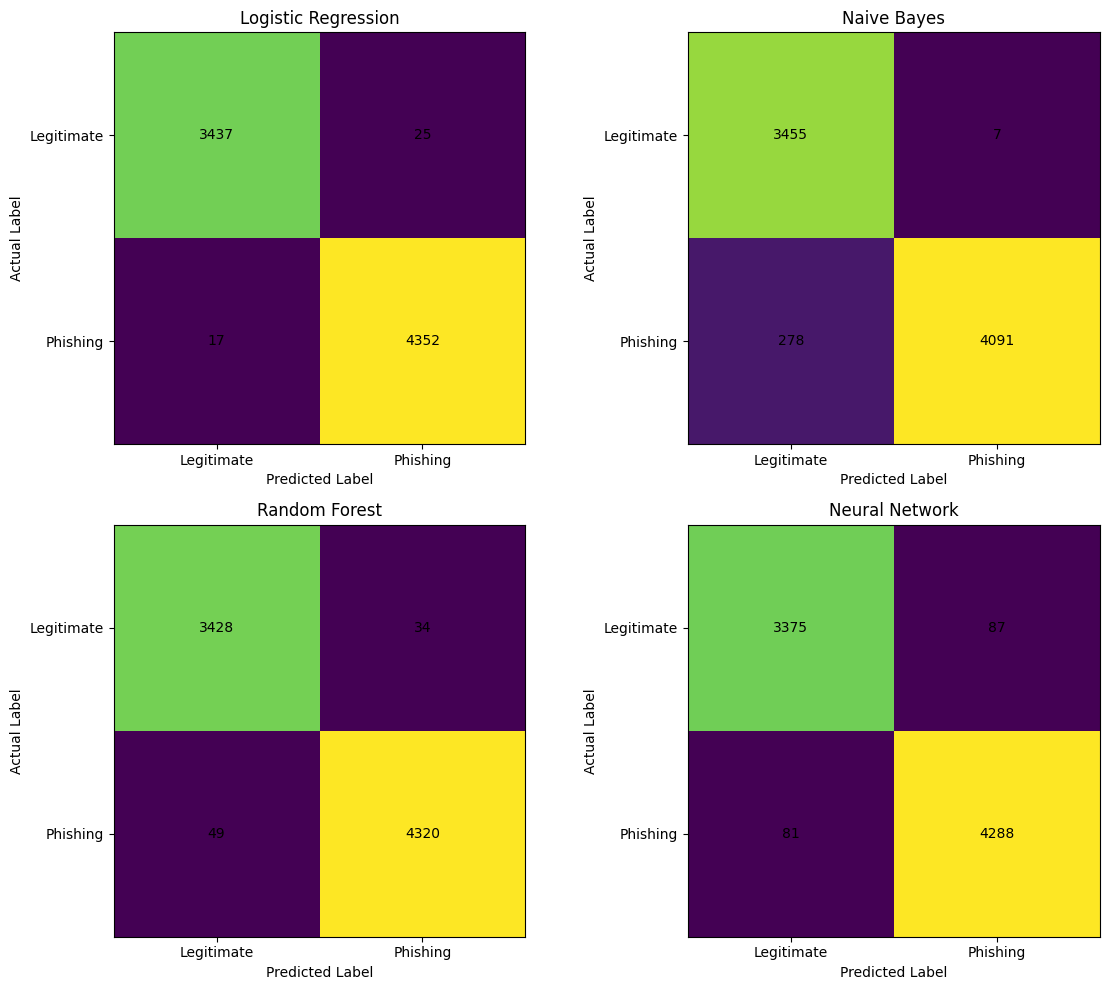

In [10]:
# confusion matrix
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)

axes = axes.ravel()

for ax, (model_name, predictions) in zip(
    axes,
    models.items()
):
    
    cm = confusion_matrix(
        y_test,
        predictions
    )
    
    ax.imshow(cm)
    
    ax.set_title(model_name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    
    ax.set_xticklabels([
        "Legitimate",
        "Phishing"
    ])
    
    ax.set_yticklabels([
        "Legitimate",
        "Phishing"
    ])
    
    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

plt.tight_layout()
plt.show()

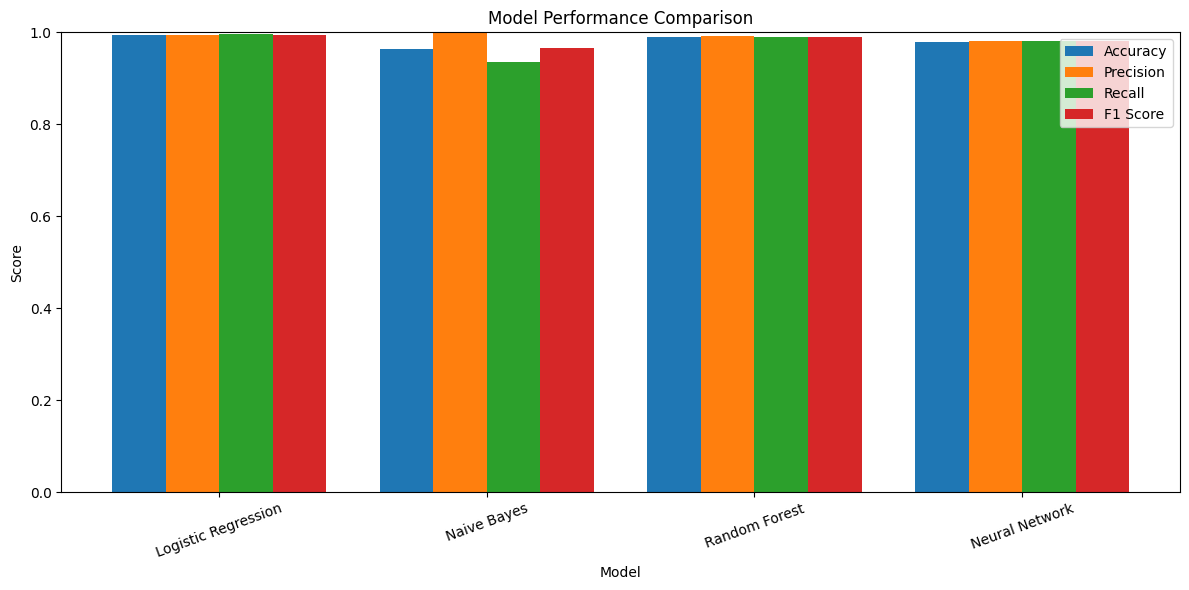

In [11]:
# model comparison graph
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

x = np.arange(len(evaluation_df["Model"]))
width = 0.2

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        evaluation_df[metric],
        width,
        label=metric
    )

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.xticks(
    x + width * 1.5,
    evaluation_df["Model"],
    rotation=20
)

plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# find the best model
best_model = evaluation_df.loc[
    evaluation_df["F1 Score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model        Logistic Regression
Accuracy                0.994637
Precision               0.994288
Recall                  0.996109
F1 Score                0.995198
Name: 0, dtype: object


In [13]:
# save evaluation results
os.makedirs("../results", exist_ok=True)

evaluation_df.to_csv(
    "../results/evaluation_results.csv",
    index=False
)

print("Evaluation results saved successfully!")

Evaluation results saved successfully!


In [14]:
evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.994637,0.994288,0.996109,0.995198
1,Naive Bayes,0.963606,0.998292,0.936370,0.966340
2,Random Forest,0.989401,0.992191,0.988785,0.990485
3,Neural Network,0.978547,0.980114,0.981460,0.980787


In [17]:
# Logistic Regression — important words
import pickle


with open("../data/processed/tfidf_vectorizer.pkl", "rb") as f:
    tfidf = pickle.load(f)

feature_names = np.array(tfidf.get_feature_names_out())

coefficients = lr_model.coef_[0]

top_phishing = np.argsort(coefficients)[-20:][::-1]
top_legitimate = np.argsort(coefficients)[:20]

print("Top Phishing-related Features:")
for i in top_phishing:
    print(feature_names[i], coefficients[i])

print("\nTop Legitimate-related Features:")
for i in top_legitimate:
    print(feature_names[i], coefficients[i])

Top Phishing-related Features:
love 5.467584470282507
men 3.6700418481439248
life 3.4746737040668565
watches 3.3356974141713067
replica 2.9718794538383055
health 2.96256129250236
ecard 2.8669872042119344
enhancement 2.351494776605389
offer 2.185660438160641
cy 2.141169280101042
sex 2.125471402523692
watch 1.9530655257357599
pleasure 1.9386139643505875
inches 1.9178701385191204
ge 1.9132420629002902
dimension 1.885772902409204
soros 1.8826302311967167
girls 1.876268913600225
pills 1.871619626582284
medications 1.864319994905769

Top Legitimate-related Features:
wrote -9.69961630531131
opensuse -6.055017287134682
thanks -4.983586610909289
ierant -4.771414315849489
use -4.327239434121173
list -4.258791890966994
pm -4.236742979500018
perl -4.006311124942518
mailing list -3.9509722941062573
im -3.934803012073919
mailing -3.8797505659279135
python -3.8239866791049346
code -3.6204873652401237
fork -3.5055740680973564
patch -3.4140561103645872
ilug -3.401946885128554
uai -3.3668635030147707
ve

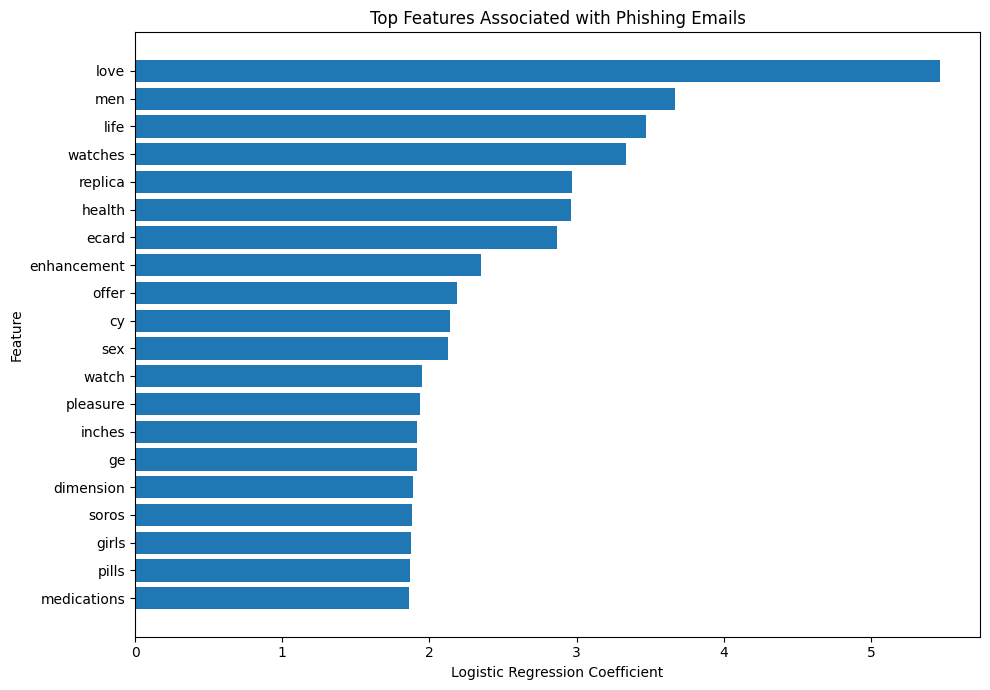

In [18]:
# Visualize top phishing features
top_features = feature_names[top_phishing]
top_values = coefficients[top_phishing]

plt.figure(figsize=(10, 7))

plt.barh(
    top_features[::-1],
    top_values[::-1]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Associated with Phishing Emails")

plt.tight_layout()
plt.show()

In [19]:
# Random Forest feature importance
rf_features = feature_names[:5000]

rf_importance = rf_model.feature_importances_

top_rf = np.argsort(rf_importance)[-20:][::-1]

print("Top Random Forest Features:")

for i in top_rf:
    print(
        rf_features[i],
        rf_importance[i]
    )

Top Random Forest Features:
list 0.057530645728904026
im 0.025507856662753264
list unsubscribe 0.025136231238671387
like 0.023004921637866032
email 0.021982192094760388
code 0.01954066119027264
file 0.016618705419749812
know 0.01338723534288775
doesnt 0.012940314014899486
hi 0.012384563662366767
feb 0.01198943363873711
address 0.011472616700514112
bug 0.010377914986804494
february 0.009895802979829645
data 0.009887613524183783
files 0.00964916606234323
id 0.009055601606660295
date 0.008741554443736374
ive 0.008585888580373163
linux 0.008447717946984151


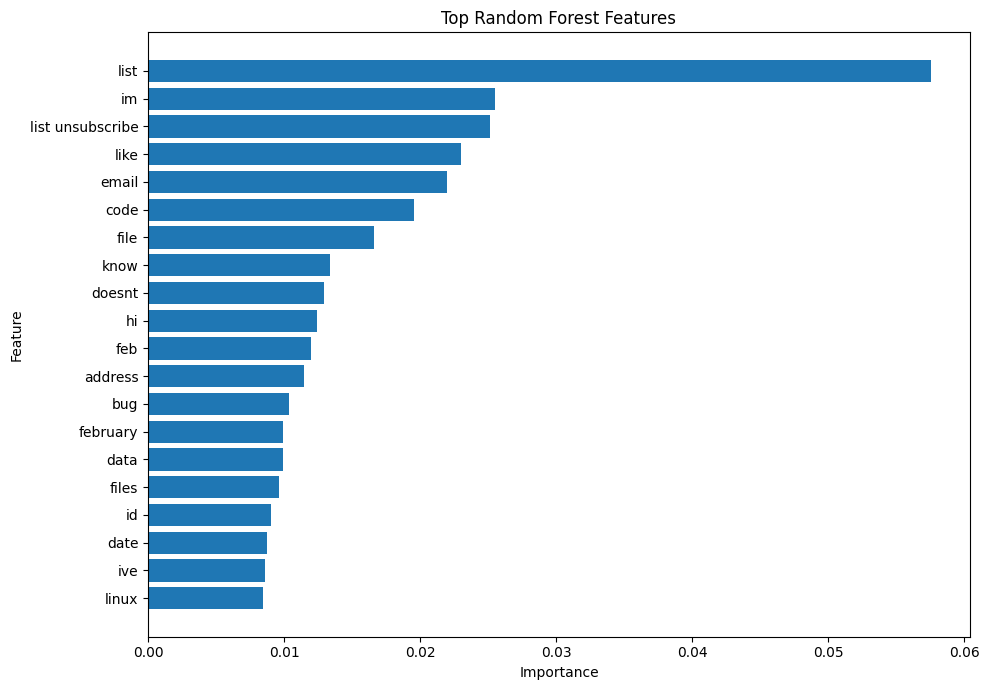

In [20]:
plt.figure(figsize=(10, 7))

plt.barh(
    rf_features[top_rf][::-1],
    rf_importance[top_rf][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Random Forest Features")

plt.tight_layout()
plt.show()

In [21]:
# Save final evaluation table
evaluation_df.to_csv(
    "../results/evaluation_results.csv",
    index=False
)

In [22]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names[top_phishing],
    "Coefficient": coefficients[top_phishing]
})

feature_importance_df.to_csv(
    "../results/top_phishing_features.csv",
    index=False
)

print("Feature importance saved!")

Feature importance saved!
